<a href="https://colab.research.google.com/github/ALISSONRABELOTEIXEIRA/1TIAOB-FASE5-CAP1/blob/main/AlissonViniciusdeSouzRabeloTeixeira_rm573512_cap1_Fase5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Análise de rendimento de safras (`crop_yield.csv`)

## Objetivo
Este notebook realiza:

1. análise exploratória da base;
2. clusterização para identificar cenários de rendimento e possíveis outliers;
3. comparação de **cinco modelos preditivos de regressão** para prever `Yield`;
4. avaliação com métricas adequadas e interpretação dos principais resultados.

## Regras adotadas
- O arquivo `crop_yield.csv` é apenas carregado; nenhuma coluna ou valor do arquivo original é alterado.
- Os nomes originais das colunas são preservados.
- Tabelas auxiliares e transformações são feitas somente em memória e dentro dos pipelines.
- Nenhum outlier é removido: os casos são apenas sinalizados para investigação.
- A separação treino/teste respeita os cenários climáticos repetidos na base, evitando que o mesmo cenário apareça nos dois conjuntos.


In [ ]:

# Bibliotecas principais para manipulação, visualização e modelagem.
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR

# Mantém a saída limpa, sem avisos não essenciais durante a execução.
warnings.filterwarnings('ignore')

# Configurações apenas de exibição; não alteram os dados.
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda valor: f'{valor:,.2f}')

SEMENTE = 42


## 1. Carregamento e análise exploratória

In [ ]:

# O dataset é carregado diretamente do repositório público no GitHub.
arquivo_csv = 'https://raw.githubusercontent.com/ALISSONRABELOTEIXEIRA/1TIAOB-FASE5-CAP1/refs/heads/main/crop_yield.csv'

# Carrega o arquivo sem modificar nomes, colunas ou valores.
dados = pd.read_csv(arquivo_csv)

print(f'Dimensões da base: {dados.shape[0]} linhas x {dados.shape[1]} colunas')
display(dados.head())


Dimensões da base: 156 linhas x 6 colunas


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans","2,248.92",17.72,83.40,26.01,11560
1,"Cocoa, beans","1,938.42",17.54,82.11,26.11,11253
2,"Cocoa, beans","2,301.54",17.81,82.79,26.24,9456
3,"Cocoa, beans","2,592.35",17.61,85.07,25.56,9321
4,"Cocoa, beans","2,344.72",17.61,84.12,25.76,8800


In [ ]:

# Confere tipos, valores ausentes, duplicidades e cardinalidade.
resumo_estrutura = pd.DataFrame({
    'tipo': dados.dtypes.astype(str),
    'ausentes': dados.isna().sum(),
    'unicos': dados.nunique(),
})

print(f'Linhas duplicadas completas: {dados.duplicated().sum()}')
display(resumo_estrutura)


Linhas duplicadas completas: 0


,tipo,ausentes,unicos
Crop,object,0,4
Precipitation (mm day-1),float64,0,39
Specific Humidity at 2 Meters (g/kg),float64,0,33
Relative Humidity at 2 Meters (%),float64,0,38
Temperature at 2 Meters (C),float64,0,29
Yield,int64,0,155



### Leitura inicial
A base é pequena, com 156 registros, 6 colunas e quatro culturas. Não há valores ausentes nem linhas totalmente duplicadas. Como o conjunto é pequeno, a avaliação dos modelos precisa ser cuidadosa para reduzir o risco de conclusões otimistas.


In [ ]:

# Estatísticas das variáveis numéricas nas unidades originais.
display(dados.describe().T)

# Resumo do rendimento por cultura.
resumo_rendimento = (
    dados.groupby('Crop')['Yield']
    .agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    .sort_values('mean', ascending=False)
)
display(resumo_rendimento)


,count,mean,std,min,25%,50%,75%,max
Precipitation (mm day-1),156.00,"2,486.50",289.46,"1,934.62","2,302.99","2,424.55","2,718.08","3,085.79"
Specific Humidity at 2 Meters (g/kg),156.00,18.20,0.29,17.54,18.03,18.27,18.40,18.70
Relative Humidity at 2 Meters (%),156.00,84.74,1.00,82.11,84.12,84.85,85.51,86.10
Temperature at 2 Meters (C),156.00,26.18,0.26,25.56,26.02,26.13,26.30,26.81
Yield,156.00,"56,153.10","70,421.96","5,249.00","8,327.75","18,871.00","67,518.75","203,399.00"


,count,mean,std,min,median,max
Crop,,,,,,
Oil palm fruit,39,"175,804.69","14,919.87",142425,"175,629.00",203399
"Rice, paddy",39,"32,099.67","4,789.95",24686,"31,101.00",42550
"Cocoa, beans",39,"8,883.13","1,745.03",5765,"8,848.00",13056
"Rubber, natural",39,"7,824.90","1,600.26",5249,"7,817.00",10285


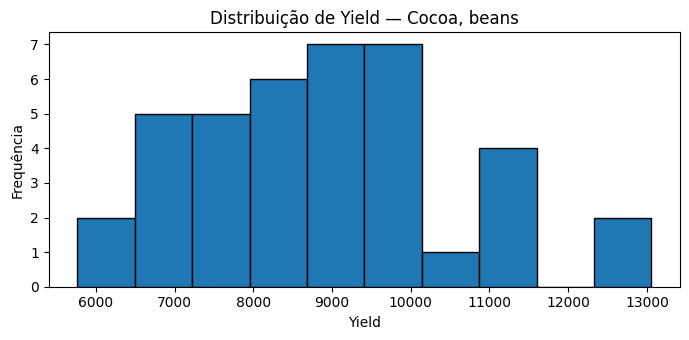

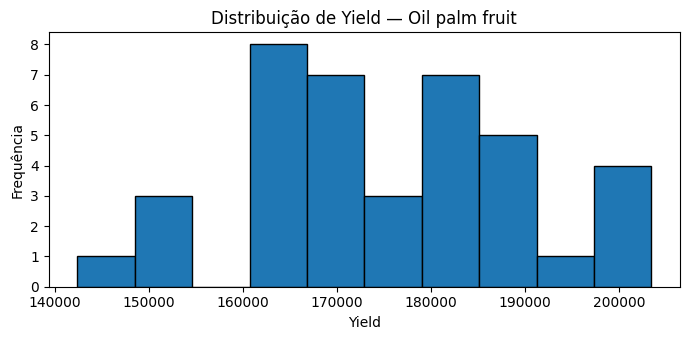

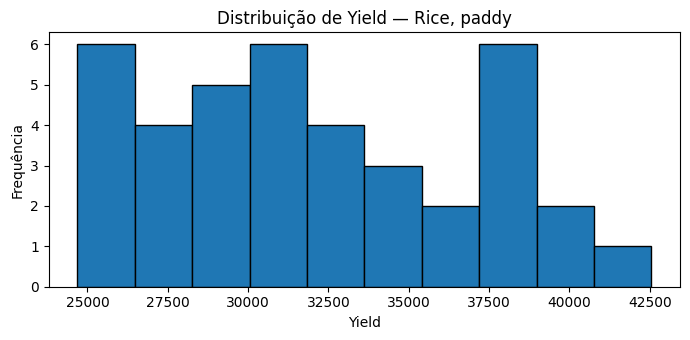

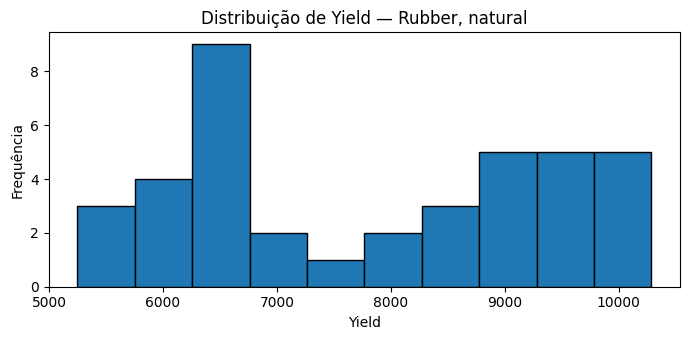

In [ ]:

# Visualiza a distribuição do rendimento por cultura sem alterar os valores.
for cultura, grupo in dados.groupby('Crop', sort=True):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.hist(grupo['Yield'], bins=10, edgecolor='black')
    ax.set_title(f'Distribuição de Yield — {cultura}')
    ax.set_xlabel('Yield')
    ax.set_ylabel('Frequência')
    plt.tight_layout()
    plt.show()


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
Precipitation (mm day-1),1.00,0.49,0.75,-0.08,0.02
Specific Humidity at 2 Meters (g/kg),0.49,1.00,0.44,0.70,0.01
Relative Humidity at 2 Meters (%),0.75,0.44,1.00,-0.34,0.00
Temperature at 2 Meters (C),-0.08,0.70,-0.34,1.00,0.01
Yield,0.02,0.01,0.00,0.01,1.00


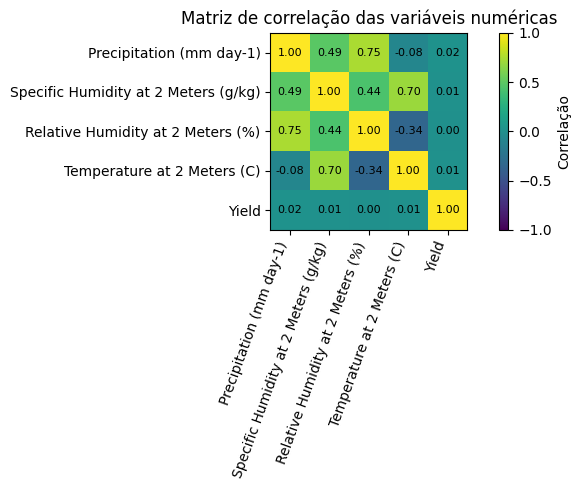

In [ ]:

# Correlação de Pearson apenas entre variáveis numéricas.
correlacoes = dados.select_dtypes(include='number').corr()
display(correlacoes.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
imagem = ax.imshow(correlacoes, vmin=-1, vmax=1)
ax.set_xticks(range(len(correlacoes.columns)), correlacoes.columns, rotation=70, ha='right')
ax.set_yticks(range(len(correlacoes.index)), correlacoes.index)
for i in range(len(correlacoes.index)):
    for j in range(len(correlacoes.columns)):
        ax.text(j, i, f'{correlacoes.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(imagem, ax=ax, label='Correlação')
ax.set_title('Matriz de correlação das variáveis numéricas')
plt.tight_layout()
plt.show()


In [ ]:

# Verifica a repetição dos mesmos cenários meteorológicos entre culturas.
colunas_clima = [
    'Precipitation (mm day-1)',
    'Specific Humidity at 2 Meters (g/kg)',
    'Relative Humidity at 2 Meters (%)',
    'Temperature at 2 Meters (C)',
]

cenarios_unicos = dados[colunas_clima].drop_duplicates().shape[0]
repeticoes_por_cenario = dados.groupby(colunas_clima, dropna=False).size()

print(f'Cenários climáticos únicos: {cenarios_unicos}')
print('Quantidade de registros por cenário climático:')
display(repeticoes_por_cenario.value_counts().sort_index().rename('quantidade_de_cenarios').to_frame())


Cenários climáticos únicos: 39
Quantidade de registros por cenário climático:


,quantidade_de_cenarios
4,39



### Achados da análise exploratória
- Cada uma das quatro culturas possui 39 registros.
- `Oil palm fruit` tem rendimento muito maior que as demais culturas, portanto comparar rendimentos absolutos sem considerar `Crop` pode ser enganoso.
- Existem 39 cenários climáticos únicos, e cada cenário aparece quatro vezes: uma vez para cada cultura.
- Essa repetição exige separação de treino/teste por cenário climático, e não por linhas aleatórias, para evitar vazamento de informação.
- As correlações lineares globais entre clima e `Yield` são fracas porque as diferenças de escala entre culturas dominam o rendimento. Isso não significa que o clima seja irrelevante dentro de cada cultura.


## 2. Clusterização e identificação de cenários discrepantes


A clusterização é feita **separadamente por cultura**. Isso evita que a diferença de escala do `Yield` entre culturas domine a formação dos grupos.

Para cada cultura:
1. padronizamos as quatro variáveis climáticas e `Yield` somente para calcular distâncias;
2. testamos de 2 a 4 clusters com K-Means;
3. escolhemos a quantidade com maior *silhouette score*;
4. calculamos a distância de cada ponto ao centro do seu cluster;
5. sinalizamos como possível outlier uma distância acima de `Q3 + 1,5 × IQR` dentro do próprio cluster.

A sinalização é exploratória. Nenhum registro é excluído.


In [ ]:

# Variáveis usadas para descrever cenários de clima + rendimento.
variaveis_cluster = colunas_clima + ['Yield']

# Cria apenas uma cópia analítica; o objeto original 'dados' permanece intacto.
resultado_cluster = dados.copy()
resultado_cluster['Cluster'] = -1
resultado_cluster['Distancia_Centroide'] = np.nan
resultado_cluster['Possivel_Outlier'] = False

resumo_clusters = []
resumo_silhueta = []

# Processa cada cultura separadamente para respeitar sua escala de rendimento.
for cultura, indices in dados.groupby('Crop', sort=True).groups.items():
    grupo = dados.loc[indices, variaveis_cluster]

    # Padronização necessária para que todas as variáveis contribuam à distância.
    escalador = StandardScaler()
    grupo_padronizado = escalador.fit_transform(grupo)

    # Escolhe k pelo maior silhouette score entre soluções simples (2 a 4 clusters).
    pontuacoes = {}
    for k in range(2, 5):
        kmeans_teste = KMeans(n_clusters=k, random_state=SEMENTE, n_init=50)
        rotulos_teste = kmeans_teste.fit_predict(grupo_padronizado)
        pontuacoes[k] = silhouette_score(grupo_padronizado, rotulos_teste)
        resumo_silhueta.append({'Crop': cultura, 'k': k, 'Silhouette': pontuacoes[k]})

    melhor_k = max(pontuacoes, key=pontuacoes.get)
    kmeans = KMeans(n_clusters=melhor_k, random_state=SEMENTE, n_init=50)
    rotulos = kmeans.fit_predict(grupo_padronizado)

    # Distância euclidiana ao centroide do cluster atribuído.
    distancias = np.linalg.norm(
        grupo_padronizado - kmeans.cluster_centers_[rotulos], axis=1
    )

    # Registra cluster e distância na tabela auxiliar.
    resultado_cluster.loc[indices, 'Cluster'] = rotulos
    resultado_cluster.loc[indices, 'Distancia_Centroide'] = distancias

    # Detecta possíveis outliers por regra IQR dentro de cada cluster.
    for cluster_id in np.unique(rotulos):
        mascara_local = rotulos == cluster_id
        distancias_cluster = distancias[mascara_local]
        q1, q3 = np.quantile(distancias_cluster, [0.25, 0.75])
        limite = q3 + 1.5 * (q3 - q1)
        indices_cluster = np.array(indices)[mascara_local]
        indices_outliers = indices_cluster[distancias_cluster > limite]
        resultado_cluster.loc[indices_outliers, 'Possivel_Outlier'] = True

    # Resume a solução escolhida por cultura.
    resumo_clusters.append({
        'Crop': cultura,
        'Melhor_k': melhor_k,
        'Silhouette': pontuacoes[melhor_k],
        'Possiveis_outliers': int(resultado_cluster.loc[indices, 'Possivel_Outlier'].sum()),
    })

resumo_clusters = pd.DataFrame(resumo_clusters)
resumo_silhueta = pd.DataFrame(resumo_silhueta)

display(resumo_clusters)


,Crop,Melhor_k,Silhouette,Possiveis_outliers
0,"Cocoa, beans",2,0.29,2
1,Oil palm fruit,3,0.32,4
2,"Rice, paddy",2,0.37,1
3,"Rubber, natural",3,0.34,2


In [ ]:

# Perfil dos clusters encontrados em cada cultura.
perfil_clusters = (
    resultado_cluster
    .groupby(['Crop', 'Cluster'])
    .agg(
        Registros=('Yield', 'size'),
        Yield_medio=('Yield', 'mean'),
        Yield_min=('Yield', 'min'),
        Yield_max=('Yield', 'max'),
        Possiveis_outliers=('Possivel_Outlier', 'sum'),
    )
    .reset_index()
)
display(perfil_clusters)


,Crop,Cluster,Registros,Yield_medio,Yield_min,Yield_max,Possiveis_outliers
0,"Cocoa, beans",0,27,"8,948.00",6530,13056,2
1,"Cocoa, beans",1,12,"8,737.17",5765,11560,0
2,Oil palm fruit,0,17,"177,074.18",160862,199074,1
3,Oil palm fruit,1,13,"169,880.85",150428,201436,2
4,Oil palm fruit,2,9,"181,963.44",142425,203399,1
5,"Rice, paddy",0,12,"27,308.83",24686,30676,0
6,"Rice, paddy",1,27,"34,228.93",25251,42550,1
7,"Rubber, natural",0,11,"8,916.00",6546,10285,2
8,"Rubber, natural",1,19,"7,835.47",5249,10159,0
9,"Rubber, natural",2,9,"6,469.00",5571,9205,0


In [ ]:

# Lista somente os cenários sinalizados; os dados originais continuam preservados.
outliers = resultado_cluster.loc[
    resultado_cluster['Possivel_Outlier'],
    ['Crop'] + colunas_clima + ['Yield', 'Cluster', 'Distancia_Centroide']
].sort_values(['Crop', 'Distancia_Centroide'], ascending=[True, False])

print(f'Total de cenários sinalizados: {len(outliers)}')
display(outliers)

Total de cenários sinalizados: 9


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,Cluster,Distancia_Centroide
35,"Cocoa, beans","2,410.13",18.58,83.45,26.81,11487,0,3.22
27,"Cocoa, beans","3,085.79",18.34,86.10,26.03,13056,0,3.20
40,Oil palm fruit,"1,938.42",17.54,82.11,26.11,201436,1,3.24
56,Oil palm fruit,"2,362.80",18.70,84.03,26.79,142425,2,3.01
42,Oil palm fruit,"2,592.35",17.61,85.07,25.56,181826,1,2.74
75,Oil palm fruit,"2,967.41",18.67,85.48,26.46,199074,0,2.43
116,"Rice, paddy","2,109.34",18.51,83.52,26.72,42550,1,3.45
120,"Rubber, natural","2,592.35",17.61,85.07,25.56,9718,0,2.51
118,"Rubber, natural","1,938.42",17.54,82.11,26.11,9223,0,2.33


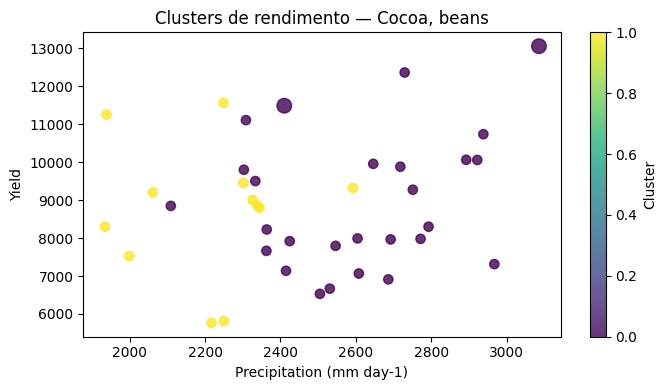

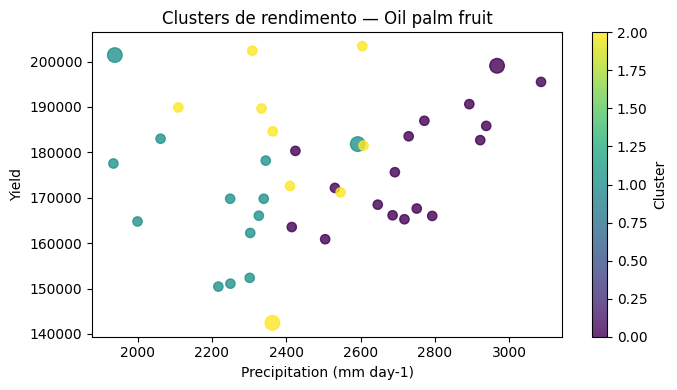

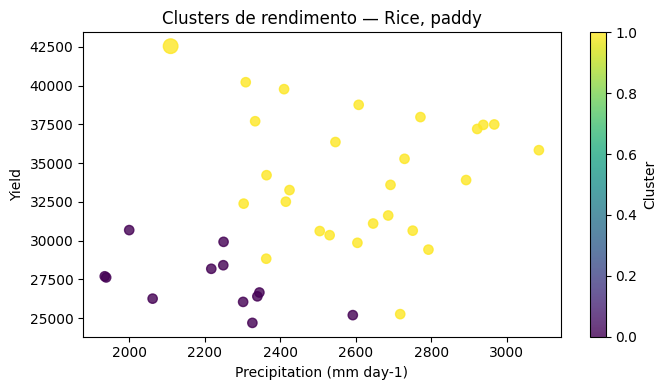

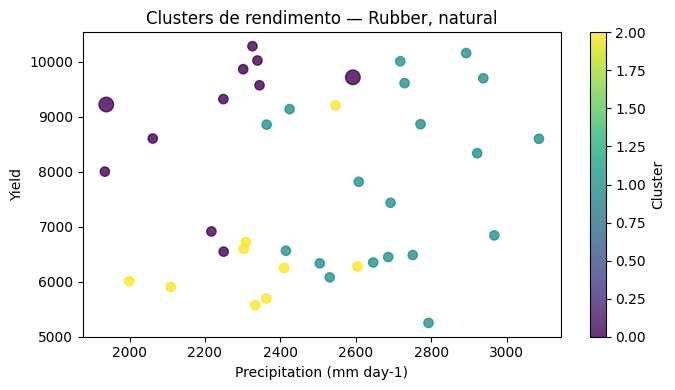

In [ ]:

# Visualiza Yield por precipitação e cluster em cada cultura.
for cultura, grupo in resultado_cluster.groupby('Crop', sort=True):
    fig, ax = plt.subplots(figsize=(7, 4))
    dispersao = ax.scatter(
        grupo['Precipitation (mm day-1)'],
        grupo['Yield'],
        c=grupo['Cluster'],
        s=np.where(grupo['Possivel_Outlier'], 110, 45),
        alpha=0.8,
    )
    ax.set_title(f'Clusters de rendimento — {cultura}')
    ax.set_xlabel('Precipitation (mm day-1)')
    ax.set_ylabel('Yield')
    fig.colorbar(dispersao, ax=ax, label='Cluster')
    plt.tight_layout()
    plt.show()



### Interpretação dos clusters
A separação é moderada, não perfeita: os melhores *silhouette scores* ficam aproximadamente entre 0,29 e 0,37. Isso indica estrutura de grupos útil para exploração, mas com sobreposição entre cenários.

Os resultados mostram perfis diferentes por cultura. `Rice, paddy` separa-se em dois grupos com níveis de rendimento bem distintos, enquanto `Oil palm fruit` e `Rubber, natural` apresentam três grupos. Os outliers sinalizados são casos distantes do padrão do próprio cluster e devem ser investigados, mas não tratados automaticamente como erro.


## 3. Modelos preditivos


### Estratégia de avaliação
O alvo é `Yield`. As variáveis de entrada são `Crop` e as quatro variáveis climáticas.

Como os mesmos 39 cenários climáticos aparecem para todas as culturas, criamos um identificador de cenário e usamos:
- **GroupShuffleSplit** para reservar 20% dos cenários como teste final;
- **GroupKFold** com 5 divisões no treino para selecionar hiperparâmetros;
- `Pipeline` + `ColumnTransformer` para aprender padronização e codificação somente com os dados de treino de cada divisão;
- MAE como métrica principal de seleção;
- RMSE, R² e MAPE como métricas complementares.

Cinco algoritmos são comparados: Ridge, KNN, SVR, Random Forest e Gradient Boosting.


In [ ]:

# Define preditores e alvo sem modificar o dataframe original.
X = dados.drop(columns='Yield')
y = dados['Yield']

colunas_categoricas = ['Crop']
colunas_numericas = colunas_clima.copy()

# Cada combinação climática recebe um grupo; linhas do mesmo cenário ficam juntas.
grupos_cenario = pd.factorize(pd.MultiIndex.from_frame(dados[colunas_clima]))[0]

# Reserva 20% dos cenários completos para teste final.
divisor = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEMENTE)
indices_treino, indices_teste = next(divisor.split(X, y, groups=grupos_cenario))

X_treino = X.iloc[indices_treino]
X_teste = X.iloc[indices_teste]
y_treino = y.iloc[indices_treino]
y_teste = y.iloc[indices_teste]
grupos_treino = grupos_cenario[indices_treino]

print(f'Treino: {len(X_treino)} linhas / {len(np.unique(grupos_treino))} cenários')
print(f'Teste:  {len(X_teste)} linhas / {len(np.unique(grupos_cenario[indices_teste]))} cenários')
print(f'Cenários em comum entre treino e teste: {len(set(grupos_treino) & set(grupos_cenario[indices_teste]))}')


Treino: 124 linhas / 31 cenários
Teste:  32 linhas / 8 cenários
Cenários em comum entre treino e teste: 0


In [ ]:

# Pré-processamento dentro do pipeline para evitar vazamento de informação.
preprocessamento = ColumnTransformer(
    transformers=[
        ('numericas', StandardScaler(), colunas_numericas),
        ('categorica', OneHotEncoder(handle_unknown='ignore', sparse_output=False), colunas_categoricas),
    ],
    verbose_feature_names_out=False,
)

# Modelos e grades compactas de hiperparâmetros.
# A busca é intencionalmente pequena para reduzir sobreajuste em uma base de 156 linhas.
modelos = {
    'Ridge': (
        Ridge(),
        [
            {'modelo__alpha': [0.1]},
            {'modelo__alpha': [1.0]},
            {'modelo__alpha': [10.0]},
        ],
    ),
    'KNN': (
        KNeighborsRegressor(),
        [
            {'modelo__n_neighbors': [3], 'modelo__weights': ['distance'], 'modelo__p': [1]},
            {'modelo__n_neighbors': [5], 'modelo__weights': ['distance'], 'modelo__p': [2]},
            {'modelo__n_neighbors': [7], 'modelo__weights': ['uniform'], 'modelo__p': [2]},
        ],
    ),
    'SVR': (
        SVR(kernel='rbf'),
        [
            {'modelo__C': [1e5], 'modelo__epsilon': [1000], 'modelo__gamma': ['scale']},
            {'modelo__C': [1e6], 'modelo__epsilon': [100], 'modelo__gamma': [0.01]},
            {'modelo__C': [1e5], 'modelo__epsilon': [100], 'modelo__gamma': [0.01]},
        ],
    ),
    'Random Forest': (
        RandomForestRegressor(random_state=SEMENTE, n_jobs=1),
        [
            {'modelo__n_estimators': [200], 'modelo__max_depth': [None], 'modelo__min_samples_leaf': [1], 'modelo__max_features': [1.0]},
            {'modelo__n_estimators': [200], 'modelo__max_depth': [8], 'modelo__min_samples_leaf': [1], 'modelo__max_features': [1.0]},
            {'modelo__n_estimators': [200], 'modelo__max_depth': [None], 'modelo__min_samples_leaf': [2], 'modelo__max_features': [1.0]},
        ],
    ),
    'Gradient Boosting': (
        GradientBoostingRegressor(random_state=SEMENTE),
        [
            {'modelo__n_estimators': [200], 'modelo__learning_rate': [0.05], 'modelo__max_depth': [3], 'modelo__min_samples_leaf': [1]},
            {'modelo__n_estimators': [300], 'modelo__learning_rate': [0.05], 'modelo__max_depth': [3], 'modelo__min_samples_leaf': [1]},
            {'modelo__n_estimators': [200], 'modelo__learning_rate': [0.10], 'modelo__max_depth': [2], 'modelo__min_samples_leaf': [1]},
        ],
    ),
}

validacao = GroupKFold(n_splits=5)


In [ ]:

# Treina, seleciona hiperparâmetros apenas no treino e avalia uma vez no teste final.
resultados_modelos = []
melhores_estimadores = {}

for nome_modelo, (estimador, grade) in modelos.items():
    pipeline = Pipeline([
        ('preprocessamento', preprocessamento),
        ('modelo', estimador),
    ])

    busca = GridSearchCV(
        estimator=pipeline,
        param_grid=grade,
        scoring='neg_mean_absolute_error',
        cv=validacao,
        n_jobs=1,
        refit=True,
    )

    busca.fit(X_treino, y_treino, groups=grupos_treino)
    previsoes = busca.predict(X_teste)

    resultados_modelos.append({
        'Modelo': nome_modelo,
        'CV_MAE': -busca.best_score_,
        'Teste_MAE': mean_absolute_error(y_teste, previsoes),
        'Teste_RMSE': mean_squared_error(y_teste, previsoes) ** 0.5,
        'Teste_R2': r2_score(y_teste, previsoes),
        'Teste_MAPE_%': mean_absolute_percentage_error(y_teste, previsoes) * 100,
        'Melhores_parametros': busca.best_params_,
    })

    melhores_estimadores[nome_modelo] = busca.best_estimator_

resultados_modelos = (
    pd.DataFrame(resultados_modelos)
    .sort_values('Teste_MAE')
    .reset_index(drop=True)
)

display(resultados_modelos)


,Modelo,CV_MAE,Teste_MAE,Teste_RMSE,Teste_R2,Teste_MAPE_%,Melhores_parametros
0,Gradient Boosting,"3,864.90","4,990.52","7,958.98",0.99,13.98,"{'modelo__learning_rate': 0.05, 'modelo__max_d..."
1,KNN,"4,223.73","5,336.14","7,792.39",0.99,14.66,"{'modelo__n_neighbors': 3, 'modelo__p': 1, 'mo..."
2,Ridge,"5,035.42","5,775.17","8,749.19",0.99,18.44,{'modelo__alpha': 0.1}
3,Random Forest,"3,715.35","5,824.71","9,762.79",0.98,14.35,"{'modelo__max_depth': None, 'modelo__max_featu..."
4,SVR,"4,806.73","6,748.25","11,018.23",0.98,17.99,"{'modelo__C': 1000000.0, 'modelo__epsilon': 10..."


In [ ]:

# Baseline simples: média de Yield por cultura calculada apenas no treino.
media_treino_por_cultura = (
    pd.DataFrame({'Crop': X_treino['Crop'], 'Yield': y_treino})
    .groupby('Crop')['Yield']
    .mean()
)
previsao_baseline = X_teste['Crop'].map(media_treino_por_cultura).to_numpy()

baseline = pd.DataFrame([{
    'Referencia': 'Média de Yield por Crop no treino',
    'Teste_MAE': mean_absolute_error(y_teste, previsao_baseline),
    'Teste_RMSE': mean_squared_error(y_teste, previsao_baseline) ** 0.5,
    'Teste_R2': r2_score(y_teste, previsao_baseline),
    'Teste_MAPE_%': mean_absolute_percentage_error(y_teste, previsao_baseline) * 100,
}])
display(baseline)


,Referencia,Teste_MAE,Teste_RMSE,Teste_R2,Teste_MAPE_%
0,Média de Yield por Crop no treino,"5,807.94","9,244.69",0.98,14.89


In [ ]:

# Seleciona o melhor modelo pelo menor MAE no teste final apenas para interpretação.
melhor_nome = resultados_modelos.loc[0, 'Modelo']
melhor_modelo = melhores_estimadores[melhor_nome]
previsoes_melhor = melhor_modelo.predict(X_teste)

print(f'Melhor resultado no teste final: {melhor_nome}')

# Métricas por cultura ajudam a enxergar desempenho em escalas muito diferentes.
metricas_por_cultura = []
for cultura in sorted(X_teste['Crop'].unique()):
    mascara = X_teste['Crop'].to_numpy() == cultura
    metricas_por_cultura.append({
        'Crop': cultura,
        'MAE': mean_absolute_error(y_teste.to_numpy()[mascara], previsoes_melhor[mascara]),
        'MAPE_%': mean_absolute_percentage_error(y_teste.to_numpy()[mascara], previsoes_melhor[mascara]) * 100,
    })

display(pd.DataFrame(metricas_por_cultura))


Melhor resultado no teste final: Gradient Boosting


,Crop,MAE,MAPE_%
0,"Cocoa, beans","2,049.97",20.90
1,Oil palm fruit,"12,662.64",6.60
2,"Rice, paddy","3,818.12",11.89
3,"Rubber, natural","1,431.35",16.51


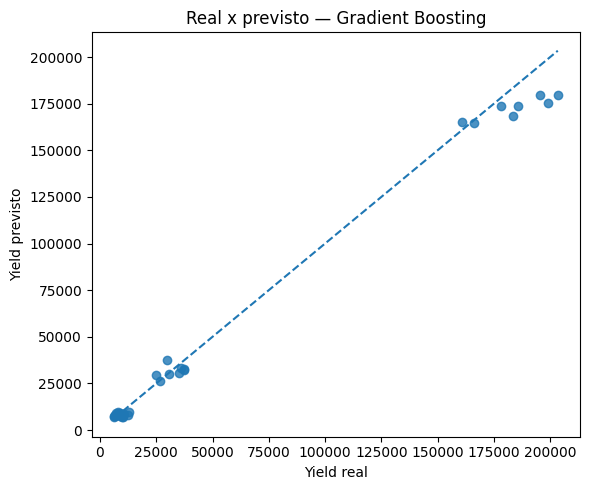

In [ ]:

# Gráfico de valores reais versus previstos do melhor modelo.
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_teste, previsoes_melhor, alpha=0.8)
limite_min = min(y_teste.min(), previsoes_melhor.min())
limite_max = max(y_teste.max(), previsoes_melhor.max())
ax.plot([limite_min, limite_max], [limite_min, limite_max], linestyle='--')
ax.set_xlabel('Yield real')
ax.set_ylabel('Yield previsto')
ax.set_title(f'Real x previsto — {melhor_nome}')
plt.tight_layout()
plt.show()


In [ ]:

# Importância por permutação no conjunto de teste, preservando as colunas originais.
# A métrica usada é MAE: quanto maior a queda de desempenho ao embaralhar a coluna, maior a dependência do modelo em relação àquela variável.
importancia = permutation_importance(
    melhor_modelo,
    X_teste,
    y_teste,
    scoring='neg_mean_absolute_error',
    n_repeats=30,
    random_state=SEMENTE,
    n_jobs=1,
)

importancia_variaveis = pd.DataFrame({
    'Variavel': X_teste.columns,
    'Importancia_media': importancia.importances_mean,
    'Desvio': importancia.importances_std,
}).sort_values('Importancia_media', ascending=False)

display(importancia_variaveis)


,Variavel,Importancia_media,Desvio
0,Crop,"67,562.69","9,007.36"
1,Precipitation (mm day-1),648.80,291.12
2,Specific Humidity at 2 Meters (g/kg),586.61,533.92
4,Temperature at 2 Meters (C),495.41,502.85
3,Relative Humidity at 2 Meters (%),-106.03,145.57



## 4. Conclusões

### Desempenho preditivo
No teste final, o **Gradient Boosting** apresentou o menor MAE, cerca de **4,99 mil unidades de Yield**, com **R² ≈ 0,988** e **MAPE ≈ 14,0%**. KNN ficou próximo e Random Forest também apresentou bom desempenho. A referência baseada apenas na média histórica de cada cultura teve MAE em torno de 5,81 mil; portanto, o melhor modelo adicionou ganho preditivo além de simplesmente reconhecer a cultura.

### Principais achados
- `Crop` é essencial porque as escalas de rendimento são muito diferentes entre culturas.
- As variáveis climáticas possuem baixa correlação linear global com `Yield`, mas ainda contribuem para discriminar cenários e melhorar a previsão.
- A clusterização encontrou estruturas moderadas, não perfeitamente separadas. Isso é coerente com um conjunto pequeno e com variáveis climáticas correlacionadas.
- Alguns cenários foram sinalizados como discrepantes pela distância ao centroide. Eles devem ser tratados como pontos de investigação, não como erros confirmados.

### Pontos fortes
- Separação treino/teste por cenário climático, evitando que condições idênticas apareçam dos dois lados.
- Pré-processamento feito dentro de `Pipeline`, reduzindo risco de vazamento.
- Comparação de cinco algoritmos diferentes com seleção de hiperparâmetros por validação cruzada em grupos.
- Uso de MAE, RMSE, R² e MAPE, além de análise por cultura.
- Nenhum dado original foi alterado ou removido.

### Limitações
- A base tem somente 156 linhas e 39 cenários climáticos únicos, o que limita a estabilidade das estimativas.
- Não há variável temporal explícita (por exemplo, ano), localização, manejo, solo, fertilização ou outras informações agronômicas que podem explicar rendimento.
- As conclusões de clusterização são exploratórias e dependem da padronização, do K-Means e da regra de distância escolhida.
- O desempenho deve ser revalidado antes de uso operacional, preferencialmente com novos períodos ou regiões realmente independentes.
